# Ngày 3 — Tracking: ByteTrack so với ReID trên clip bạn vừa gán nhãn

Notebook này làm đúng ba việc:

1. Chạy **YOLO26 + ByteTrack** làm control trên `clip_01` — chính clip bạn vừa gán nhãn tay.
2. Chạy **YOLO26 + BoT-SORT-ReID** với cùng detector input như một system treatment appearance-assisted.
3. Xuất cả hai kết quả ra **cùng định dạng MOT 1.1**, rồi chấm với cùng một bộ công cụ.

> **Chỉ chạy notebook này SAU KHI đã qua cổng annotation.**
> Xem kết quả của model trước khi tự gán xong rất dễ khiến bạn tin nhầm vào model.
> Model không phải đáp án — nó chỉ chỉ chỗ đáng ngờ.


## 1. Lấy repo và cài thư viện

**Cách 1 (repo public)** — clone fork của bạn. Sửa `REPO_URL` thành URL Git thô của fork,
ví dụ `https://github.com/ten-cua-ban/Day3-Lab.git`. Không dán Markdown dạng `[tên](URL)`.
Notebook cần đọc nhãn bạn đã commit trong `annotations/`.

**Cách 2 (repo private, không dùng token)** — trên GitHub chọn **Code → Download ZIP**,
upload ZIP vào Colab, giải nén nó thành `/content/Day3-Lab/`, rồi để nguyên `REPO_URL`
mặc định và chạy lại cell này. Nếu chưa push nhãn, upload tay `gt.txt` vào
`annotations/clip_01/` bằng bảng Files bên trái Colab.


In [1]:
REPO_URL = "https://github.com/kietminh04/K4-L2-DAY03-VuMinhKiet-2A202602300-VideoTracking.git"  # <-- SỬA DÒNG NÀY
LAB_DIR  = "Day3-Lab"

import os, sys, subprocess, json
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

def find_root(start: Path):
    """Tìm thư mục Day3-Lab bằng mốc data/clips/clip_01/seqinfo.ini."""
    for base in [start, *start.parents]:
        for candidate in (base, base / LAB_DIR):
            if (candidate / "data" / "clips" / "clip_01" / "seqinfo.ini").exists():
                return candidate.resolve()
    return None

if REPO_URL.startswith("[") or "](" in REPO_URL:
    raise ValueError(
        "REPO_URL phải là URL Git thô, không phải Markdown. Ví dụ: \n",
        'https://github.com/ten-cua-ban/Day3-Lab.git'
    )

ROOT = find_root(Path.cwd())
if ROOT is None and IN_COLAB and not REPO_URL.startswith("https://github.com/<"):
    clone = subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, LAB_DIR], text=True, capture_output=True
    )
    if clone.returncode:
        raise RuntimeError(
            "Không clone được repo. Kiểm URL Git thô (không có [ ] hoặc ( )). \n"
            "Nếu repo private, Colab không tự có quyền đọc: GitHub → Code → Download ZIP; \n"
            "upload và giải nén thành /content/Day3-Lab/, rồi để REPO_URL mặc định và chạy lại.\n\n"
            + clone.stderr
        )
    ROOT = find_root(Path.cwd())

assert ROOT is not None, (
    "Chưa thấy Day3-Lab. Dùng URL Git thô của repo public, hoặc upload ZIP private "
    "và giải nén thành /content/Day3-Lab/."
)
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "tools"))
print("ROOT =", ROOT)


ROOT = /content/Day3-Lab


In [2]:
%pip install --quiet "ultralytics==8.4.145" "lap==0.5.13"
import importlib.metadata as metadata
import ultralytics
print("ultralytics", ultralytics.__version__)
print("lap", metadata.version("lap"))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 2.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
ultralytics 8.4.145
lap 0.5.13


## 2. Kiểm tra dữ liệu trước khi chạy

Cell này dừng sớm nếu thiếu frame hoặc thiếu nhãn — rẻ hơn nhiều so với chạy tracker
190 frame rồi mới phát hiện đường dẫn sai.


In [3]:
from motlib import parse_mot, by_track, by_frame

CLIP      = ROOT / "data" / "clips" / "clip_01"
MY_LABELS = ROOT / "annotations" / "clip_01" / "gt.txt"
GOLD      = ROOT / "gold" / "clip_01" / "gt.txt"
OUT       = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

frames = sorted((CLIP / "img1").glob("*.jpg"))
seqinfo = dict(
    line.split("=", 1)
    for line in (CLIP / "seqinfo.ini").read_text().splitlines()
    if "=" in line and not line.startswith("[")
)
print("clip_01: {} frame · {}x{} @ {} fps".format(
    len(frames), seqinfo["imWidth"], seqinfo["imHeight"], seqinfo["frameRate"]))
assert len(frames) == int(seqinfo["seqLength"]), "Thiếu frame — kiểm tra lại thư mục img1/"

HAS_MINE = MY_LABELS.exists()
HAS_GOLD = GOLD.exists()

if HAS_MINE:
    mine = parse_mot(MY_LABELS)
    print("nhãn của bạn : {} bbox · {} track".format(len(mine), len(by_track(mine))))
else:
    print("CHƯA CÓ nhãn của bạn tại {} — upload gt.txt vào đó rồi chạy lại.".format(MY_LABELS))

if HAS_GOLD:
    gold = parse_mot(GOLD)
    print("gold         : {} bbox · {} track".format(len(gold), len(by_track(gold))))
else:
    print("CHƯA CÓ gold tại {}.".format(GOLD))
    print("Lab Coach phát ở mốc 2:35. Chưa có gold thì notebook vẫn chạy,")
    print("chỉ bỏ qua hai phép so cần gold.")


clip_01: 190 frame · 960x540 @ 12.5 fps
nhãn của bạn : 609 bbox · 10 track
gold         : 573 bbox · 8 track


## 3. Tracking-by-detection và ReID

Nhắc lại slide: tracker **không** nhìn cả video một lượt. Nó làm hai bước, lặp lại từng frame:

1. **Detector** (YOLO) tìm bbox trên frame hiện tại — đúng bài toán Ngày 2, không có ký ức gì.
2. **Association** (ByteTrack) nối bbox mới với track cũ, dựa trên vị trí Kalman dự đoán và
   độ chồng lấp IoU. Đây là bước sinh ra `track_id`.

ByteTrack khác các tracker cũ đúng một chỗ: nó **không vứt bbox điểm thấp**. Vòng 1 khớp bbox
điểm cao; vòng 2 lấy những bbox điểm thấp còn lại và thử khớp tiếp — vì một chiếc xe bị che
một phần vẫn là xe thật, chỉ là detector kém tự tin hơn.

Hai tham số quan trọng trong cell dưới:

- `persist=True` — giữ trạng thái tracker giữa các frame. **Thiếu nó thì mỗi frame là một clip
  mới** và `track_id` bị đánh lại từ đầu, kết quả thành vô nghĩa.
- `classes=[2, 5, 7]` — chỉ lấy `car`, `bus`, `truck` của COCO. Gold chỉ gán xe bốn bánh, nên
  nếu để model bắt cả `motorcycle` (class 3) và người thì mọi bbox đó đều thành FP.

### ReID là cue thứ ba, không phải đáp án

Khi hai xe overlap hoặc một xe vừa hiện lại sau occlusion, motion + IoU có thể mơ hồ. ReID
tạo embedding từ crop xe rồi hỏi: **vừa gần vị trí, vừa giống appearance thì có phải cùng track không?**
BoT-SORT-ReID giữ motion/IoU và thêm cue appearance. Nó không nhận diện xe ngoài đời, không sửa
detection bị thiếu và không chắc thắng ByteTrack. Xem `docs/day3-reid-theory.md` trước khi đọc metric.


In [4]:
import inspect
import run_tracker

# Đọc luôn mã nguồn của vòng lặp tracking — chỉ khoảng 20 dòng.
print(inspect.getsource(run_tracker.track_clip))


def track_clip(clip: Path, model_name: str, tracker: str, conf: float, iou: float,
               imgsz: int, classes: list[int], device: str | None = None,
               verbose: bool = True) -> list[tuple[int, int, float, float, float, float, float]]:
    """Trả về list (frame, track_id, x, y, w, h, conf) với frame đánh số từ 1."""
    from ultralytics import YOLO

    images = sorted((clip / "img1").glob("*.jpg"))
    if not images:
        raise SystemExit(f"Không thấy ảnh trong {clip / 'img1'}")

    model = YOLO(model_name)
    rows: list[tuple[int, int, float, float, float, float, float]] = []

    for index, image_path in enumerate(images, start=1):
        # persist=True giữ trạng thái tracker giữa các frame — thiếu nó thì mỗi
        # frame là một clip mới và track_id bị đánh lại từ đầu.
        results = model.track(
            source=str(image_path), persist=True, tracker=tracker,
            conf=conf, iou=iou, imgsz=imgsz, classes=classes,
            device=device, ve

In [5]:
import platform
import torch

DEVICE  = "0" if torch.cuda.is_available() else "cpu"
MODEL   = "yolo26n.pt"
CONF    = 0.25
IOU     = 0.70
IMGSZ   = 960
CLASSES = [2, 5, 7]

# Hai run giữ detector input cố định; tracker implementation/association khác nhau.
RUNS = {
    "bytetrack": {
        "label": "ByteTrack control",
        "tracker": "bytetrack.yaml",
        "out": OUT / "model_bytetrack_clip_01.txt",
    },
    "reid": {
        "label": "BoT-SORT + ReID treatment",
        "tracker": str(ROOT / "configs" / "trackers" / "botsort-reid.yaml"),
        "out": OUT / "model_reid_clip_01.txt",
    },
}

run_config = {
    "python": platform.python_version(),
    "ultralytics": ultralytics.__version__,
    "torch": torch.__version__,
    "lap": metadata.version("lap"),
    "weights": MODEL,
    "runs": {name: {"label": run["label"], "tracker": run["tracker"]}
             for name, run in RUNS.items()},
    "conf": CONF,
    "iou": IOU,
    "imgsz": IMGSZ,
    "classes": CLASSES,
    "device": DEVICE,
    "persist": True,
    "clip_frames": len(frames),
}
MODEL_CONFIG = OUT / "model_run_config.json"
MODEL_CONFIG.write_text(json.dumps(run_config, indent=2) + "\n", encoding="utf-8")
print("Cấu hình đã khóa:", json.dumps(run_config, indent=2))
print("Chạy trên {}. Trên CPU mất vài phút, trên GPU nhanh hơn.".format(DEVICE))

MODEL_OUTS = {}
for run_name, run in RUNS.items():
    print("\n=== {} ===".format(run["label"]))
    rows = run_tracker.track_clip(
        clip=CLIP, model_name=MODEL, tracker=run["tracker"],
        conf=CONF, iou=IOU, imgsz=IMGSZ, classes=CLASSES, device=DEVICE,
    )
    run_tracker.write_mot(rows, run["out"])
    MODEL_OUTS[run_name] = run["out"]
    dets = parse_mot(run["out"])
    print("{}: {} bbox · {} track -> {}".format(
        run["label"], len(dets), len(by_track(dets)), run["out"]))

# Treatment được dùng để tìm frame model ↔ bạn bất đồng ở phần sau.
MODEL_OUT = MODEL_OUTS["reid"]
model_dets = parse_mot(MODEL_OUT)


Cấu hình đã khóa: {
  "python": "3.13.15",
  "ultralytics": "8.4.145",
  "torch": "2.11.0+cu128",
  "lap": "0.5.13",
  "weights": "yolo26n.pt",
  "runs": {
    "bytetrack": {
      "label": "ByteTrack control",
      "tracker": "bytetrack.yaml"
    },
    "reid": {
      "label": "BoT-SORT + ReID treatment",
      "tracker": "/content/Day3-Lab/configs/trackers/botsort-reid.yaml"
    }
  },
  "conf": 0.25,
  "iou": 0.7,
  "imgsz": 960,
  "classes": [
    2,
    5,
    7
  ],
  "device": "0",
  "persist": true,
  "clip_frames": 190
}
Chạy trên 0. Trên CPU mất vài phút, trên GPU nhanh hơn.

=== ByteTrack control ===
  frame 25/190 · 62 bbox tích luỹ
  frame 50/190 · 107 bbox tích luỹ
  frame 75/190 · 171 bbox tích luỹ
  frame 100/190 · 236 bbox tích luỹ
  frame 125/190 · 366 bbox tích luỹ
  frame 150/190 · 492 bbox tích luỹ
  frame 175/190 · 575 bbox tích luỹ
ByteTrack control: 607 bbox · 16 track -> /content/Day3-Lab/outputs/model_bytetrack_clip_01.txt

=== BoT-SORT + ReID treatment ===


## 4. Chấm control và treatment

Cùng một script `tools/evaluate_tracking.py`, bốn phép so, bốn câu hỏi khác nhau:

| So sánh | Trả lời câu hỏi |
| --- | --- |
| bạn vs gold | nhãn tay của bạn tốt đến đâu |
| ByteTrack vs gold | control giữ ID tốt đến đâu trên clip này |
| BoT-SORT + ReID vs gold | treatment appearance-assisted thay đổi quality/identity thế nào |

> Đây là system comparison, không cô lập causal effect của ReID: ByteTrack và BoT-SORT khác implementation.
| ReID vs bạn | chỗ nào treatment và nhãn tay không đồng ý — đáng soi nhất |

So **IDF1, AssA, IDSW** trước; sau đó đọc DetA, FP/FN và worst frames. Không so hai model
với nhau như một model là gold.


In [6]:
def evaluate(pred, gt, mode, out_json, pred_label, gt_label):
    """Gọi đúng script bạn đã chạy ở terminal, để số liệu không lệch nhau."""
    result = subprocess.run(
        [sys.executable, str(ROOT / "tools" / "evaluate_tracking.py"),
         "--pred", str(pred), "--gt", str(gt),
         "--seqinfo", str(CLIP / "seqinfo.ini"),
         "--mode", mode, "--output", str(out_json),
         "--pred-label", pred_label, "--gt-label", gt_label],
        capture_output=True, text=True,
    )
    print(result.stdout or result.stderr)
    return json.loads(Path(out_json).read_text()) if Path(out_json).exists() else None

results = {}

if HAS_MINE and HAS_GOLD:
    results["ban_vs_gold"] = evaluate(
        MY_LABELS, GOLD, "annotation", OUT / "eval_vs_gold.json",
        "nhãn của bạn", "gold clip_01")
else:
    print("Bỏ qua: cần cả nhãn của bạn và gold.")


  nhãn của bạn  vs  gold clip_01
  clip: clip_01 · 190 frame · IoU ngưỡng 0.5
  HOTA 0.732   = sqrt(DetA x AssA)   -- điểm tổng của tracking
    DetA 0.688  tìm đúng vật thể chưa (giống bài toán Ngày 2)
    AssA 0.781  giữ đúng ID chưa      (phần riêng của tracking)
    LocA 0.838  bbox khít đến đâu
--------------------------------------------------------------------------
  IDF1 0.915   MOTA 0.826   MOTP 0.812
  FP 68  FN 32  ID switch 0   |  bbox gold 573  bbox của bạn 609  |  track gold 8  track của bạn 10
  CỔNG QUA BÀI
    [ĐẠT ] IDF1  0.915  (cần >= 0.80)
    [ĐẠT ] MOTA  0.825  (cần >= 0.75)
    [ĐẠT ] MOTP  0.812  (cần >= 0.70)
  => ĐẠT — sang bước chạy model

  3. BBOX TREO / BBOX THỪA — ID của bạn tồn tại ở nơi không có vật thể  (3)
    - ID 7: không khớp track tham chiếu nào (frame 106-122, 17 frame) -> bấm outside đúng frame xe rời khung
    - ID 10: không khớp track tham chiếu nào (frame 167-183, 17 frame) -> bấm outside đúng frame xe rời khung
    - ID 6: đã có bbox trước

In [7]:
if HAS_GOLD:
    for run_name, run in RUNS.items():
        results[run_name + "_vs_gold"] = evaluate(
            MODEL_OUTS[run_name], GOLD, "model", OUT / ("eval_" + run_name + "_vs_gold.json"),
            MODEL + " + " + run["label"], "gold clip_01")
else:
    print("Bỏ qua: chưa có gold.")


  yolo26n.pt + ByteTrack control  vs  gold clip_01
  clip: clip_01 · 190 frame · IoU ngưỡng 0.5
  HOTA 0.709   = sqrt(DetA x AssA)   -- điểm tổng của tracking
    DetA 0.649  tìm đúng vật thể chưa (giống bài toán Ngày 2)
    AssA 0.776  giữ đúng ID chưa      (phần riêng của tracking)
    LocA 0.846  bbox khít đến đâu
--------------------------------------------------------------------------
  IDF1 0.875   MOTA 0.749   MOTP 0.823
  FP 88  FN 54  ID switch 2   |  bbox gold 573  bbox của model 607  |  track gold 8  track của model 16

  1. ID SWITCH của model — tracker đổi ID giữa chừng  (2)
    - frame 59: track gold 4 đang là ID 14 -> nhảy sang ID 15
    - frame 94: track gold 5 đang là ID 23 -> nhảy sang ID 32

  2. TÁCH TRACK — tracker cắt một xe thành nhiều ID (thường sau lúc bị che)  (3)
    - track gold 4 (95 frame) bị chia cho ID [15, 14]
    - track gold 5 (60 frame) bị chia cho ID [32, 23]
    - track gold 7 (85 frame) bị chia cho ID [52, 71]

  3. BBOX THỪA của model — ID không

In [8]:
if HAS_MINE:
    results["reid_vs_ban"] = evaluate(
        MODEL_OUTS["reid"], MY_LABELS, "peer", OUT / "eval_reid_vs_me.json",
        MODEL + " + " + RUNS["reid"]["label"], "nhãn của bạn")
else:
    print("Bỏ qua: chưa có nhãn của bạn.")


  yolo26n.pt + BoT-SORT + ReID treatment  vs  nhãn của bạn
  clip: clip_01 · 190 frame · IoU ngưỡng 0.5
  HOTA 0.772   = sqrt(DetA x AssA)   -- điểm tổng của tracking
    DetA 0.719  tìm đúng vật thể chưa (giống bài toán Ngày 2)
    AssA 0.832  giữ đúng ID chưa      (phần riêng của tracking)
    LocA 0.895  bbox khít đến đâu
--------------------------------------------------------------------------
  IDF1 0.903   MOTA 0.806   MOTP 0.876
  FP 72  FN 43  ID switch 3   |  bbox bản A 609  bbox bản B 638  |  track bản A 10  track bản B 16

  1. HAI BẢN LỆCH ID — cùng một xe nhưng hai người theo hai ID khác nhau  (3)
    - frame 87: track bản A 5 đang là ID 17 -> nhảy sang ID 18
    - frame 107: track bản A 6 đang là ID 24 -> nhảy sang ID 28
    - frame 110: track bản A 6 đang là ID 28 -> nhảy sang ID 31

  2. MỘT BÊN TÁCH TRACK — xe bị chia thành nhiều ID ở một trong hai bản  (3)
    - track bản A 6 (67 frame) bị chia cho ID [31, 24, 28]
    - track bản A 5 (62 frame) bị chia cho ID [18, 17

### Bảng tổng hợp

Đây là bảng bạn chép vào báo cáo.


In [9]:
ORDER = ["HOTA", "DetA", "AssA", "LocA", "IDF1", "MOTA", "MOTP", "FP", "FN", "IDSW"]

header = "{:<16}".format("") + "".join("{:>8}".format(k) for k in ORDER)
print(header)
print("-" * len(header))
for name, res in results.items():
    m = res["metrics"]
    row = "{:<16}".format(name)
    for k in ORDER:
        v = m[k]
        row += "{:>8.3f}".format(v) if isinstance(v, float) else "{:>8d}".format(v)
    print(row)

if "ban_vs_gold" in results:
    g = results["ban_vs_gold"]["gate"]
    print("\nCổng annotation:", "ĐẠT" if g["passed"] else "CHƯA ĐẠT",
          {k: round(v["value"], 3) for k, v in g["checks"].items()})


                    HOTA    DetA    AssA    LocA    IDF1    MOTA    MOTP      FP      FN    IDSW
------------------------------------------------------------------------------------------------
ban_vs_gold        0.732   0.688   0.781   0.838   0.915   0.826   0.812      68      32       0
bytetrack_vs_gold   0.709   0.649   0.776   0.846   0.875   0.749   0.823      88      54       2
reid_vs_gold       0.763   0.711   0.820   0.872   0.900   0.792   0.860      91      26       2
reid_vs_ban        0.772   0.719   0.832   0.895   0.903   0.806   0.876      72      43       3

Cổng annotation: ĐẠT {'IDF1': 0.915, 'MOTA': 0.825, 'MOTP': 0.812}


### Nhìn metric trước khi soi frame

Biểu đồ này chỉ dùng metric tổng hợp; không chứa bbox hay ID của teaching reference.


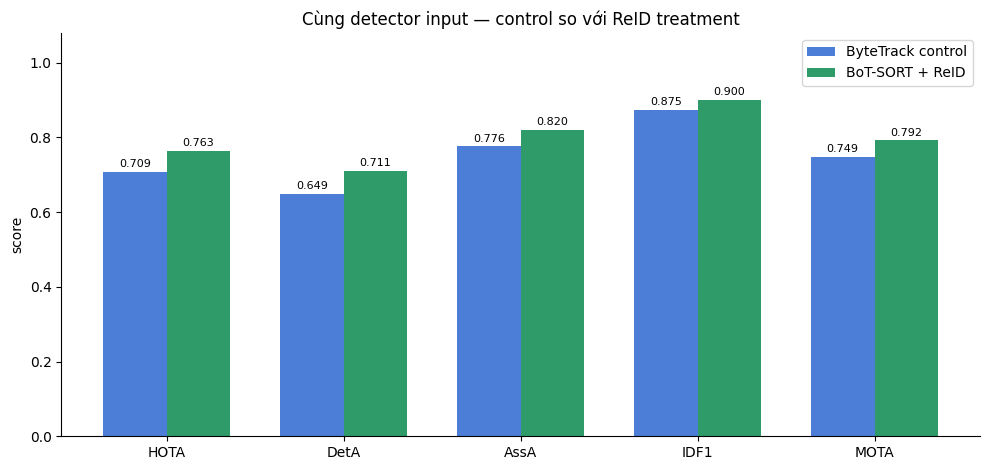

In [10]:
import matplotlib.pyplot as plt

if "bytetrack_vs_gold" in results and "reid_vs_gold" in results:
    metric_names = ["HOTA", "DetA", "AssA", "IDF1", "MOTA"]
    control = [results["bytetrack_vs_gold"]["metrics"][name] for name in metric_names]
    treatment = [results["reid_vs_gold"]["metrics"][name] for name in metric_names]
    import numpy as np
    x = np.arange(len(metric_names))
    fig, ax = plt.subplots(figsize=(10, 4.8))
    left = ax.bar(x - .18, control, .36, label="ByteTrack control", color="#4C7ED8")
    right = ax.bar(x + .18, treatment, .36, label="BoT-SORT + ReID", color="#2E9B68")
    ax.set_xticks(x, metric_names)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("score")
    ax.set_title("Cùng detector input — control so với ReID treatment")
    ax.legend()
    ax.bar_label(left, labels=["{:.3f}".format(value) for value in control], padding=2, fontsize=8)
    ax.bar_label(right, labels=["{:.3f}".format(value) for value in treatment], padding=2, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("Bỏ qua biểu đồ: chưa có teaching reference.")


## 5. Tìm chỗ bạn và ReID treatment không đồng ý

Điểm số nói *bao nhiêu*, không nói *ở đâu*. Cell dưới xếp hạng từng frame theo mức bất đồng
giữa nhãn của bạn và ReID treatment, rồi vẽ ra để bạn nhìn tận mắt.

Cách đọc, theo đúng slide:

- **Treatment có bbox, bạn không** → có thể bạn bỏ sót xe nhỏ/rìa, hoặc treatment là FP. Kiểm tra ngay.
- **Bạn có bbox, treatment không** → có thể detector bỏ sót xe bị che. Bạn nhiều khả năng đúng.
- **Cùng có bbox, khác ID** → soi kỹ nhất. Một trong hai đã gán sai ID lúc hai xe cắt nhau.

Cẩn thận với loại thứ nhất: treatment vẫn có thể bắt nhầm **vật thể tĩnh** (quầy hàng, bốt điện, xe
in trên biển quảng cáo) thành xe. Bbox đó tồn tại hàng chục frame mà không nhúc nhích — nhìn
`track đứng im` là nhận ra ngay. Đó là model sai, không phải bạn thiếu.


In [11]:
from motlib import iou, linear_sum_assignment

def disagreement_by_frame(a_dets, b_dets, threshold=0.5):
    """Mỗi frame: đếm bbox chỉ có ở A, chỉ có ở B, và cặp khớp nhau nhưng lệch ID."""
    a_frames, b_frames = by_frame(a_dets), by_frame(b_dets)
    pairing = {}
    report = {}
    for f in sorted(set(a_frames) | set(b_frames)):
        A, B = a_frames.get(f, []), b_frames.get(f, [])
        matched = []
        if A and B:
            score = [[iou(x, y) for y in B] for x in A]
            matched = [(i, j)
                       for i, j in linear_sum_assignment([[-v for v in r] for r in score])
                       if score[i][j] >= threshold]
        for i, j in matched:
            key = (A[i].track_id, B[j].track_id)
            pairing[key] = pairing.get(key, 0) + 1
        report[f] = dict(only_a=len(A) - len(matched), only_b=len(B) - len(matched),
                         matched=[(A[i].track_id, B[j].track_id) for i, j in matched])
    best = {}
    for (a_id, b_id), n in sorted(pairing.items(), key=lambda kv: -kv[1]):
        best.setdefault(a_id, b_id)
    for f, r in report.items():
        r["id_mismatch"] = sum(1 for a_id, b_id in r["matched"] if best.get(a_id) != b_id)
        r["score"] = r["only_a"] + r["only_b"] + 2 * r["id_mismatch"]
    return report

WORST_FRAMES = []
if HAS_MINE:
    dis = disagreement_by_frame(parse_mot(MODEL_OUT), parse_mot(MY_LABELS))
    worst = sorted(dis.items(), key=lambda kv: -kv[1]["score"])[:8]
    print("{:>6}{:>14}{:>14}{:>10}".format("frame", "chỉ model có", "chỉ bạn có", "khác ID"))
    for f, r in worst:
        print("{:>6}{:>14}{:>14}{:>10}".format(f, r["only_a"], r["only_b"], r["id_mismatch"]))
    WORST_FRAMES = [f for f, _ in worst[:4]]


 frame  chỉ model có    chỉ bạn có   khác ID
    91             1             2         0
   105             2             1         0
   108             2             1         0
   109             2             1         0
    56             2             0         0
    79             1             1         0
    96             1             1         0
    98             1             1         0


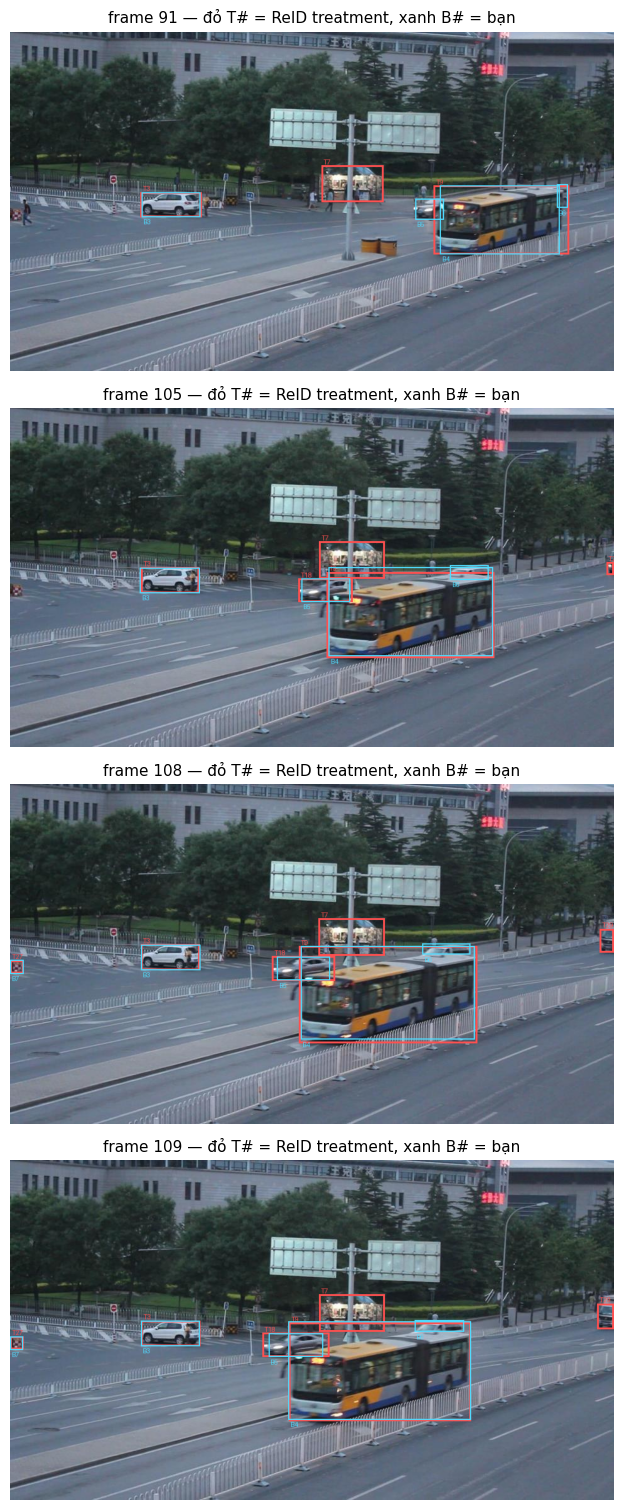

In [12]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

def draw(frame_index, a_dets, b_dets, a_colour=(255, 80, 80), b_colour=(80, 220, 255)):
    image = Image.open(CLIP / "img1" / "{:06d}.jpg".format(frame_index)).convert("RGB")
    canvas = ImageDraw.Draw(image)
    for det in by_frame(a_dets).get(frame_index, []):
        canvas.rectangle((det.x, det.y, det.x + det.w, det.y + det.h), outline=a_colour, width=3)
        canvas.text((det.x + 3, max(0, det.y - 12)), "T{}".format(det.track_id), fill=a_colour)
    for det in by_frame(b_dets).get(frame_index, []):
        canvas.rectangle((det.x, det.y, det.x + det.w, det.y + det.h), outline=b_colour, width=2)
        canvas.text((det.x + 3, det.y + det.h + 2), "B{}".format(det.track_id), fill=b_colour)
    return image

if WORST_FRAMES:
    model_dets, my_dets = parse_mot(MODEL_OUT), parse_mot(MY_LABELS)
    fig, axes = plt.subplots(len(WORST_FRAMES), 1, figsize=(13, 7.6 * len(WORST_FRAMES) / 2))
    axes = axes.ravel() if len(WORST_FRAMES) > 1 else [axes]
    for ax, f in zip(axes, WORST_FRAMES):
        ax.imshow(draw(f, model_dets, my_dets))
        ax.set_title("frame {} — đỏ T# = ReID treatment, xanh B# = bạn".format(f), fontsize=11)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## 6. Stretch: ngưỡng ReID

Core giữ tất cả ngưỡng cố định. Chạy cell này chỉ khi còn thời gian: thử `appearance_thresh`
thấp/trung/cao rồi giải thích trade-off bằng IDF1, IDSW và một frame. Không chọn ngưỡng theo
gold để sửa annotation; đây là diagnostic stretch, không cộng lợi thế điểm.

Chạy cell này nếu còn thời gian; không bắt buộc, nhưng một dòng nhận xét về nó làm báo cáo
của bạn khác hẳn.


In [14]:
RUN_EXPERIMENT = True   # đổi thành True nếu còn thời gian

if RUN_EXPERIMENT and HAS_GOLD:
    from motlib import hota, identity, clear_mot
    gold_dets = parse_mot(GOLD)
    print("{:<28}{:>7}{:>7}{:>7}{:>7}{:>6}{:>6}{:>6}".format(
        "cấu hình", "HOTA", "DetA", "AssA", "IDF1", "FP", "FN", "IDSW"))
    template = (ROOT / "configs" / "trackers" / "botsort-reid.yaml").read_text()
    for appearance_value in (0.70, 0.80, 0.90):
        tracker_path = OUT / "stretch_reid_{}.yaml".format(str(appearance_value).replace(".", "_"))
        tracker_path.write_text(template.replace("appearance_thresh: 0.80", "appearance_thresh: {}".format(appearance_value)))
        rows_ = run_tracker.track_clip(
            clip=CLIP, model_name=MODEL, tracker=str(tracker_path), conf=CONF,
            iou=IOU, imgsz=IMGSZ, classes=CLASSES, device=DEVICE, verbose=False)
        tmp = OUT / "tmp_reid_{}.txt".format(str(appearance_value).replace(".", "_"))
        run_tracker.write_mot(rows_, tmp)
        p = parse_mot(tmp)
        h, i, c = hota(gold_dets, p), identity(gold_dets, p), clear_mot(gold_dets, p)
        label = "ReID appearance={}".format(appearance_value)
        print("{:<28}{:>7.3f}{:>7.3f}{:>7.3f}{:>7.3f}{:>6d}{:>6d}{:>6d}".format(
            label, h["HOTA"], h["DetA"], h["AssA"], i["IDF1"], c["FP"], c["FN"], c["IDSW"]))
else:
    print("Bỏ qua thí nghiệm (RUN_EXPERIMENT=False hoặc chưa có gold).")


cấu hình                       HOTA   DetA   AssA   IDF1    FP    FN  IDSW
ReID appearance=0.7           0.763  0.711  0.820  0.900    91    26     2
ReID appearance=0.8           0.763  0.711  0.820  0.900    91    26     2
ReID appearance=0.9           0.763  0.710  0.820  0.899    91    27     2


## 7. Câu hỏi phải trả lời trong báo cáo

Chép bảng tổng hợp ở mục 4 vào `reports/REPORT.md`, rồi trả lời:

1. **MOTA của bạn cao hơn hay thấp hơn IDF1?** Nếu MOTA cao mà IDF1 thấp, nhãn của bạn sai ở
   ID chứ không phải ở chỗ bỏ sót. Vì sao MOTA lại không phạt nặng lỗi đó?
2. **ByteTrack control và BoT-SORT + ReID treatment khác nhau thế nào ở IDF1, AssA, IDSW?** Dẫn một frame
   sequence để giải thích treatment tốt hơn, tệ hơn hay không đổi. Không quy chênh lệch chỉ cho ReID:
   hai tracker implementation khác nhau.
3. **DetA, FP và FN đổi thế nào?** Có phải lỗi còn lại là detector, hay là association?
4. Tìm **một chỗ bạn đúng và ReID sai**, và **một chỗ ReID đúng mà bạn cần xem lại**. Ghi rõ frame, ID,
   và lý do; không sửa annotation chỉ vì model nói khác.
5. Nếu phải gán thêm 10 clip nữa, bạn sẽ **sửa gì trong `GUIDELINE_MINI.md`** để người gán
   tiếp theo không mắc lại lỗi bạn vừa mắc?

Đừng quên commit `outputs/*.json`, `outputs/model_bytetrack_clip_01.txt` và
`outputs/model_reid_clip_01.txt` cùng báo cáo.

Đính kèm `outputs/model_run_config.json` để Lab Coach tái lập đúng lần chạy của bạn.
